# Seasonal Forecast Analysis

### Emily Zuetell
### August 3, 2026
### v08 August 17, 2026

# Initialization

In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib
importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

# Load Data

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

#Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_TAS_FORECAST_RAW_URI"]

In [3]:
#Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated = False)
baseline_period = analysis_utils.get_baseline_period(effect, years = 30)
#Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

#Socioeconomics
socioeconomics =  xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year = 2026)[['pop0to4', 'pop5to64', 'pop65plus', 'pop', 'gdppc', 'iso3']]

# Mortality Level

In [ ]:
_polygons_effect = analysis_utils.xarray_to_gpd(effect["/forecast"]['effect'].sel(age_cohort = 'age65plus').mean(dim = ['number', 'sample']).sum(dim = "time"), _polygons)


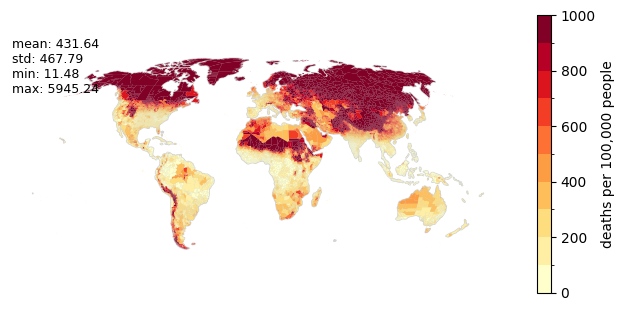

In [22]:
annotation = analysis_utils.build_stats_text(effect["/forecast"]['effect'].sel(age_cohort = 'age65plus').mean(dim = ['number', 'sample']).sum(dim = "time"))

ax = analysis_utils.plot_single(
    _polygons_effect,
    col='effect',
    cm = 'YlOrRd',
    n_colors = 10,
    vmin = 0, vmax = 1000,
    sup_title="",
    annotation = annotation,
    cbar_label= effect["/forecast"]['effect'].units,
)

# Compute Impact

In [6]:
#Compute the Mortality Impact relative to a Baseline Period for the Projected Effects
impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = "net", rate = True, age_weight = True)

##For a single age-cohort, use:
#impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = False, baseline_period=baseline_period, hotonly = False, rate = True, age_weight = False, cohort = 'age65plus')

# Uncertainty

In [ ]:
_polygons_impact = analysis_utils.xarray_to_gpd(impact.mean(dim = ['number', 'sample']), _polygons)

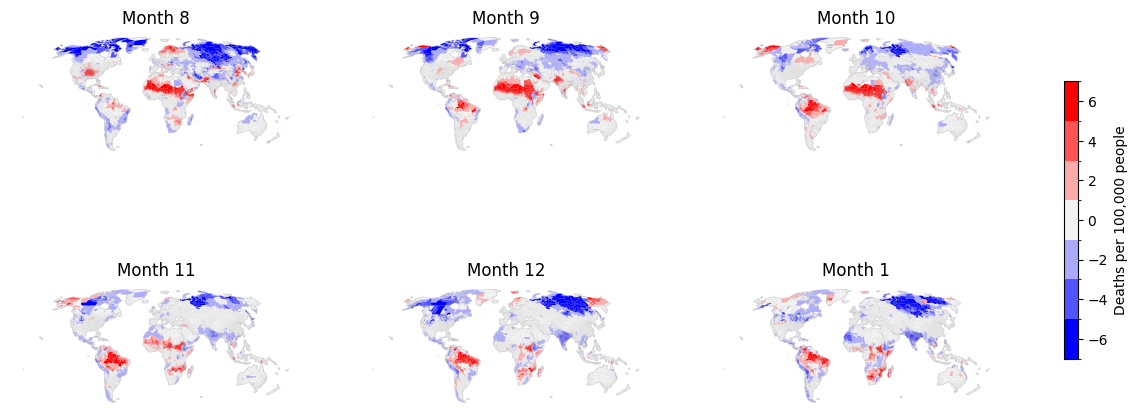

In [12]:
# Plot Impact on a Monthly Basis
fig = analysis_utils.plot_monthly(
    _polygons_impact,
    col='age_weighted_impact',
    cm = 'bwr',
    sup_title="",
    cbar_label= impact.units,
    month_order= [8, 9, 10, 11, 12, 1]
)


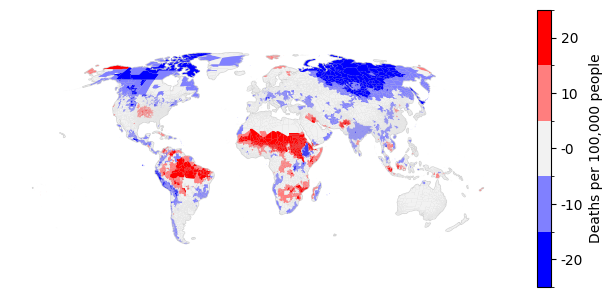

In [13]:
# Plot 6-month Cumulative Impact
fig = analysis_utils.plot_aggregate(
    _polygons_impact,
    col='age_weighted_impact',
    agg = 'sum',
    cm = 'bwr',
    sup_title="",
    cbar_label= impact.units,
)

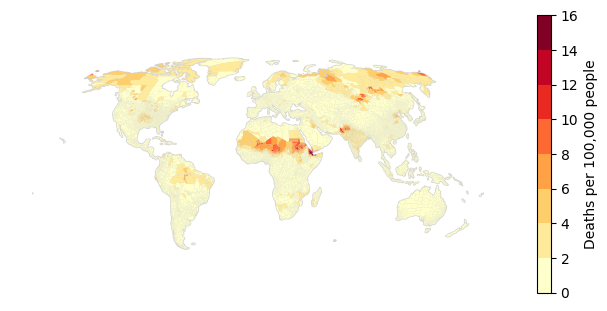

In [14]:
#Ex: Plot 6-month SD
fig = analysis_utils.plot_aggregate(
    _polygons_impact,
    col='age_weighted_impact',
    agg = 'std',
    cm = 'YlOrRd',
    sup_title="",
    cbar_label= impact.units,
)

# Climate Data

## Raw Forecast

In [7]:
forecast = xr.open_zarr(os.path.join(DATA_DIR, TAS_FORECAST_URI))
# Gridded to Impact Region
forecast_ir = isku_utils.grid_to_ir(forecast.mean(dim = 'number'), savefile = None)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ]  # Load only what we need.
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [14]:
_polygons_forecast = analysis_utils.xarray_to_gpd(forecast_ir['tas'].groupby('time.month').mean(), _polygons)

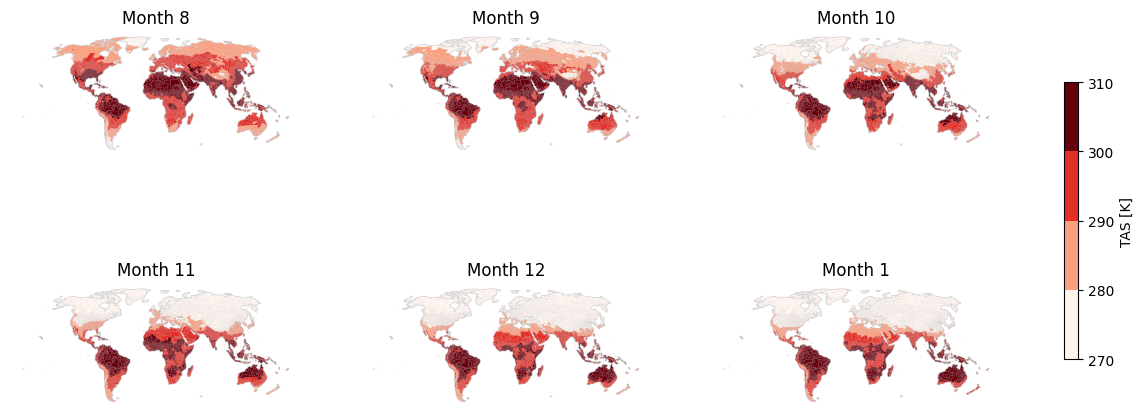

In [16]:
fig = analysis_utils.plot_monthly(
    _polygons_forecast,
    col='tas',
    vmin = 273.15,
    vmax = 303,
    cm = 'Reds',
    sup_title="",
    cbar_label= 'TAS [K]',
    month_order= [8, 9, 10, 11, 12, 1]
)

## Forecast Anomaly

In [33]:
#Raw Forecast/Hindcast
s51 = xr.open_zarr(os.path.join(DATA_DIR, TAS_FORECAST_RAW))
forecast = s51.sel(time=slice('2026-08-01', '2027-01-31')).groupby("time.month").mean()
hindcast = s51.sel(time=slice('1996-08-01', '2025-01-31')).groupby("time.month").mean().sel(month = [1, 8, 9, 10, 11, 12])

In [34]:
anomaly = forecast['tas']-hindcast['tas']
anomaly.name = "forecast_anomaly"

In [35]:
anomaly_ir = isku_utils.grid_to_ir(anomaly.compute(), savefile = None)
_polygons_anomaly = analysis_utils.xarray_to_gpd(anomaly_ir.mean(dim = 'number'), _polygons)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


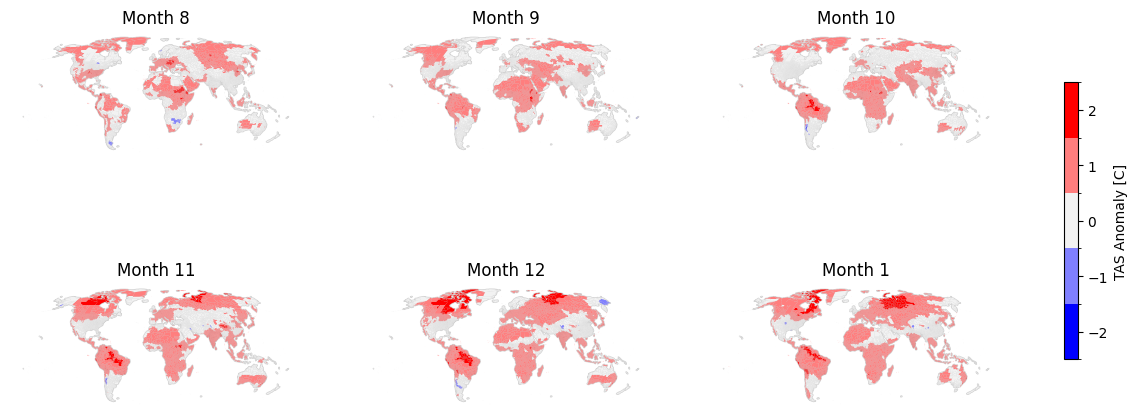

In [12]:
fig = analysis_utils.plot_monthly(
    _polygons_anomaly,
    col='value',
    cm = 'bwr',
    sup_title="",
    cbar_label= 'TAS Anomaly [C]',
    month_order= [8, 9, 10, 11, 12, 1]
)

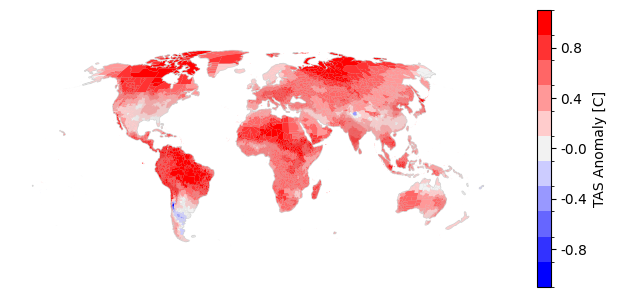

In [14]:
#6 month average anomaly
fig = analysis_utils.plot_aggregate(
    _polygons_anomaly,
    col='value',
    agg = 'mean',
    cm = 'bwr',
    n_colors = 9,
    sup_title="",
    cbar_label= 'TAS Anomaly [C]',
)

## ERA5 Baseline

In [62]:
era5 = xr.open_zarr(os.path.join(DATA_DIR, ERA5_URI))
era5_ir = isku_utils.grid_to_ir(era5.compute(), savefile = None)

ds = era5_ir
era5_ir = ds.assign_coords(month=ds.time.dt.month)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [64]:
era5_ir.to_zarr("era5_baseline.zarr")

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [ ]:
stat_cols = ['median', 'p17', 'p83', 'likely_range_IPCC', 
                'mean','std', 
                'min', 'max', 
                'p10', 'p90']
stats_impact = analysis_utils.compute_stats(anomaly_ir, dim=["number"], polygon=_polygons)

wide = stats_impact.pivot(index=['region', "geometry"], columns="month", values=stat_cols)
wide = wide.reset_index(level="geometry")
wide = gpd.GeoDataFrame(wide, geometry="geometry")
wide.columns = ["_".join(map(str, col)) for col in wide.columns]

wide.to_parquet("2608_monthly_anomaly.parquet")

# Build CSV

In [37]:
impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = "net", rate = False, age_weight = True)

In [38]:
global_rate = impact.sum(dim = 'region')*100000/socioeconomics['pop'].sum(dim = 'region')

In [39]:
stat_cols = ['median', 'p17', 'p83', 'likely_range_IPCC', 
                'mean','std', 
                'min', 'max', 
                'p10', 'p90']
_polygons_impact = analysis_utils.compute_stats(global_rate.sum(dim = 'month').compute(), dim=["number", "sample"])

In [40]:
df = _polygons_impact.to_pandas()

In [41]:
df

median               -2.764383
p17                  -6.014425
p83                   2.189251
likely_range_IPCC     8.203676
mean                 -2.106080
std                   3.929924
min                 -13.735066
max                   6.970672
p10                  -7.159600
p90                   3.042044
dtype: float64

In [42]:
df.to_csv("2608_net_6mo_rate_global.csv")

In [ ]:
# Monthly Stats

wide = _polygons_impact.pivot(index=['region', 'ISO'], columns="month", values=stat_cols)
wide.columns = [f"month {m} {stat}" for stat, m in wide.columns]
wide = wide.reset_index()
wide.to_csv(f"2608_{hotonly}_{rate_l}_all_stats.csv", index = False)

In [ ]:
analysis_utils.make_csv(effect, socioeconomics, ensemble = True, 
        baseline_period=baseline_period, hotonly = "coldonly", 
         rate = False, age_weight = True)

# Response Function Plot

In [ ]:
### TEST DATA ###
# IR Climate Data
forecast_gmfd = xr.open_zarr(os.path.join(DATA_DIR, "daily_forecast_GMFD_tas.zarr"))-273.15
reanalysis_gmfd = xr.open_zarr(os.path.join(DATA_DIR, "daily_reanalysis_GMFD_tas.zarr"))-273.15

#Intermediate Betas/MMT from Project.Py
betas_mmt = xr.open_zarr(os.path.join(DATA_DIR, "beta_mmt_GMFD.zarr"))

In [ ]:


import diagnostic_utils
importlib.reload(diagnostic_utils)

### Analysis Options ###
rate = True # Mortality Rate vs Total Deaths
hotonly = False # Hot-Only Deaths
age_weight = False #Proportional Age-weighting vs single age group
density_hist = False #Controls daily data histograms (not computation normalization)

### Region Selection ###
region_filters = [
    "PAK.2.5.27",
    "IND.16.203.735",
    "BRA.7.804.1862",
    "IND.29.439.1743",
    "CHN.11.109.767",  # set to None for global
    "COD.3.15.51",
    "THA.76.909.5787",
    "HRV.R4acd3465906d6fba",
    "EGY.8",
    "BRA.9.R7ae8d9b7a4e0454f",
    "ZMB.9.67",
    "USA.14.608",
]

region_filter = "EGY.8"

# Compute Impact
projected = effect
regional_sum = analysis_utils.compute_impact(projected, socioeconomics, baseline_period= baseline_period, hotonly = hotonly, rate = rate, age_weight = age_weight)

#Get Months
months = regional_sum.month.values

### Load Climate Data ###
#Select representative ensemble member
forecast_slice = forecast_gmfd['tas'].sel(number = 1)
forecast_local = forecast_slice.sel(region = region_filter)

#Select representative year
reanalysis_slice = reanalysis_gmfd['tas'].sel(time=slice('2000-01-01', '2000-12-31'))
month_mask = reanalysis_slice.month.isin(months).compute()
reanalysis_slice = reanalysis_slice.where(month_mask, drop=True)
reanalysis_local = reanalysis_slice.sel(region = region_filter)

combined = np.concat([forecast_local.values.flatten(), reanalysis_local.values.flatten()])
xmin, xmax = np.percentile(combined, [1, 100])

# Compute Cumulative Effect
cdf_data, max_cdf = diagnostic_utils.compute_cumulative_effect(forecast_slice, reanalysis_slice, region_filter, months, hotonly = hotonly)

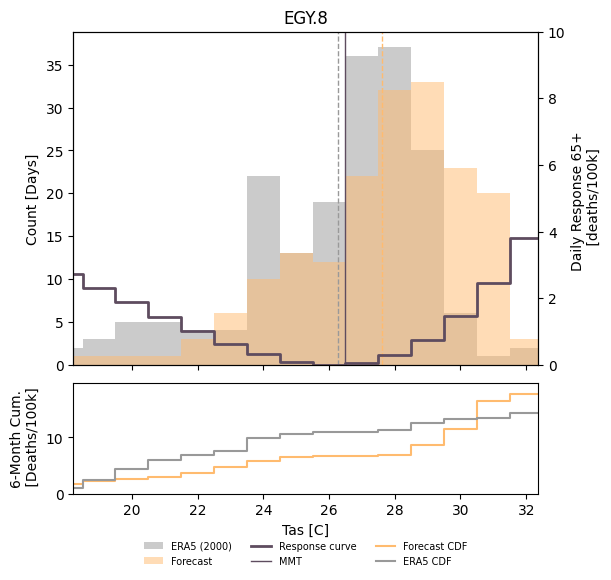

In [26]:
#Histogram

b_color = "#999999"
f_color = "#ffbb6f"
r_color = "#5e4c5f"

fig, (ax_hist, ax_cdf) = plt.subplots(
    2, 1, sharex=True, figsize=(6, 6),
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08}
)


ref_vals = betas_mmt['mmt'].sel(region=region_filter).sel(age_cohort='age65plus')
betas = betas_mmt['beta_hotonly'] if hotonly else betas_mmt['beta']
da_temp_bins = betas.sel(region=region_filter).sel(age_cohort='age65plus')
da_temp_bins['tas_bin'] = da_temp_bins['tas_bin'] 

# Density histograms on hidden twin axis
bins = da_temp_bins.coords['tas_bin']
ax_hist.hist(reanalysis_local.values.flatten(), bins=bins, alpha=0.5, label="ERA5 (2000)", density=density_hist, color=b_color)
ax_hist.hist(forecast_local.values.flatten(), bins=bins, alpha=0.5, label="Forecast", density=density_hist, color=f_color)
ax_hist.axvline(forecast_local.values.flatten().mean(), color=f_color, linewidth=1, linestyle='--')
ax_hist.axvline(reanalysis_local.values.flatten().mean(), color=b_color, linewidth=1, linestyle='--')
ax_hist.set_ylabel("Count [Days]")
ax_hist.set_xlim(xmin, xmax)

# Response curve on the primary (left) axis
ax_hist2 = ax_hist.twinx()
ax_hist2.step(da_temp_bins.coords['tas_bin'], da_temp_bins.values, where='pre', color=r_color, linewidth=2, label="Response curve")
ax_hist2.axvline(ref_vals.values, color=r_color, linewidth=1, label="MMT")
ax_hist2.set_ylabel("Daily Response 65+ \n [deaths/100k]")
ax_hist2.set_ylim(0, 10)
ax_hist2.set_xlim(xmin, xmax)

# Weighted CDFs in their own subplot below
era5_centers, era5_cdf, fc_centers, fc_cdf = cdf_data

ax_cdf.set_ylabel("6-Month Cum.\n [Deaths/100k]")
ax_cdf.set_ylim(0, max_cdf+2)
ax_cdf.set_xlim(xmin, xmax)
ax_cdf.set_xlabel("Tas [C]")
ax_cdf.step(fc_centers, fc_cdf, where='post', color=f_color, label="Forecast CDF")
ax_cdf.step(era5_centers, era5_cdf, where='post', color=b_color, label="ERA5 CDF")

#Legend
handles = (ax_hist.get_legend_handles_labels()[0]
            + ax_hist2.get_legend_handles_labels()[0]
            + ax_cdf.get_legend_handles_labels()[0])
labels = (ax_hist.get_legend_handles_labels()[1]
            + ax_hist2.get_legend_handles_labels()[1]
            + ax_cdf.get_legend_handles_labels()[1])
ax_cdf.legend(handles, labels, fontsize=7, loc='upper center',
                bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False)
ax_hist.set_title(f'{region_filter}')
fig.savefig(f'response_diagnostic_{region_filter}_2607.png', dpi=600, bbox_inches="tight")